<div align="center">

# Auditoria completa

</div>

Este fluxo analítico de auditoria foi estruturado com o objetivo principal de filtrar a massa de dados e entregar transações e portadores com indícios de irregularidades para subsidiar a tomada de decisão em investigações conduzidas por auditores humanos. Para alcançar essa assertividade, a metodologia combina duas abordagens complementares de aprendizado de máquina:

* **Segmentação de Perfis com K-Means:** O algoritmo não supervisionado agrupa os portadores com base em métricas normalizadas de volume total e ticket médio, dividindo-os em três perfis intuitivos (baixo consumo, gastos moderados e alto consumo). A escolha por três grupos equilibra a interpretabilidade e a precisão estatística, isolando com clareza o segmento de maior expressão financeira sem fragmentar excessivamente a análise.
* **Detecção de Anomalias com Isolation Forest:** Enquanto o K-Means agrupa por semelhança de comportamento geral, o Isolation Forest atua mapeando desvios estatísticos complexos utilizando um conjunto abrangente de features comportamentais. Ele é escolhido por sua alta eficiência em isolar o top um por cento de observações atípicas que fogem do padrão da massa de dados.
* **Cruzamento de Dados para o Foco Investigativo:** A união lógica entre o perfil de maior risco financeiro do K-Means e os alertas comportamentais do Isolation Forest reduz os falsos positivos e refina o escopo. O resultado prático é a entrega de uma lista priorizada e de um relatório executivo em PDF que fornecem o suporte documental necessário para otimizar o tempo e a precisão do auditor humano na triagem dos casos suspeitos.
* **Relatório e Auditoria em PDF:** Exibição detalhada de uma tabela de auditoria com os principais portadores suspeitos e exportação automatizada de um relatório executivo formatado para subsidiar a investigação humana com segurança e discernimento.

# Segmentação de Perfis de Consumo com K-Means



Tem como objetivo agrupar os CPFs da base de dados de gastos públicos por similaridade de comportamento de consumo. Para isso, utilizaremos o algoritmo de aprendizado de máquina não supervisionado **K-Means**.

### O que será feito neste notebook:
1. **Importação e Autenticação:** Conexão segura com o GitHub utilizando um token armazenado nos *Secrets* do Google Colab para baixar a base em formato `.parquet`.
2. **Seleção de Variáveis:** Filtragem das colunas de comportamento geral de gastos:
   - `VOLUME_TOTAL_LOG_SCALED`: Volume total gasto (normalizado).
   - `TICKET_MEDIO_LOG_SCALED`: Valor médio por transação (normalizado).
3. **Treinamento do Modelo (K-Means):** O algoritmo vai rodar em toda a base e aproximar os CPFs que possuem números parecidos nessas duas métricas, dividindo-os em 3 grupos (clusters).
4. **Padronização Lógica das Etiquetas:** Reorganização automática dos grupos para garantir uma interpretação intuitiva:
   - **`0`**: Grupo que gasta pouco
   - **`1`**: Grupo de gastos moderados
   - **`2`**: Grupo que gasta mais (gasta muito)

      A divisão em três grupos (0: Gasta Pouco, 1: Gastos Moderados e 2: Gasta Muito) foi escolhida por equilibrar a interpretabilidade analítica e a precisão estatística ao segmentar o comportamento de consumo na base de gastos públicos. Essa granularidade separa claramente os portadores de despesas cotidianas ou de baixo volume daqueles com maior expressão financeira, permitindo direcionar com eficiência as auditorias subsequentes para o perfil de maior risco sem sobrecarregar a análise com excesso de partições.

5. **Resultado Prático:** Criação da nova coluna `cluster_kmeans` na base de dados, categorizando cada linha, seguida de um gráfico de dispersão para visualização dos perfis formados.

**Instalação e Importação de Bibliotecas**

In [1]:
import io
import os
import base64
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.ensemble import IsolationForest
from dotenv import load_dotenv

# Carrega as variáveis de segurança do arquivo .env local
load_dotenv()
github_token = os.getenv('GITHUB_TOKEN')

# Configuração visual padrão para os gráficos
sns.set_theme(style="whitegrid")
print("Bibliotecas importadas com sucesso e variáveis locais carregadas!")

Bibliotecas importadas com sucesso e variáveis locais carregadas!


**Download da Base**

Linhas e colunas da camada Gold

In [2]:
if not github_token:
    print("Aviso: Token GITHUB_TOKEN não encontrado no .env. Tentando acesso público...")

# URL no formato raw atualizada para o seu repositório
url = "https://raw.githubusercontent.com/MaiccGms8/gov-spend-analyzer/main/gold/camada_gold.parquet"

headers = {}
if github_token:
    headers["Authorization"] = f"token {github_token}"

print("Baixando a base de dados do GitHub...")
response = requests.get(url, headers=headers)

if response.status_code == 200:
    # Leitura do arquivo parquet diretamente em memória
    df = pd.read_parquet(io.BytesIO(response.content))
    print(f"Sucesso! Base carregada com {df.shape[0]:,} linhas e {df.shape[1]} colunas.")
else:
    raise Exception(f"Erro ao baixar o arquivo. Status code: {response.status_code}. Verifique se o token GITHUB_TOKEN está configurado no .env.")

# Exibindo as primeiras linhas para validação
display(df[['HASH_CPF_PORTADOR', 'VOLUME_TOTAL_LOG_SCALED', 'TICKET_MEDIO_LOG_SCALED']].head(3))

Baixando a base de dados do GitHub...
Sucesso! Base carregada com 2,810 linhas e 19 colunas.


,HASH_CPF_PORTADOR,VOLUME_TOTAL_LOG_SCALED,TICKET_MEDIO_LOG_SCALED
0,000edd7142e0a18d234c19e52222ad8fa27230eab85cca...,-1.458633,-2.201331
1,0044817ad2e2f83f9f53d70c07731412d0c4880b13d7aa...,-0.597081,-1.356829
2,0048938b883fdd9eb27e4021a1e0e9e87d389933382be1...,-0.700652,0.013905


**Treinamento do K-Means e Classificação dos Perfis**



1. **Seleção de Variáveis (X)**
Extrai do DataFrame apenas as duas variáveis normalizadas (VOLUME_TOTAL_LOG_SCALED e TICKET_MEDIO_LOG_SCALED) e as converte em uma matriz numérica. O K-Means precisa dessas coordenadas numéricas para calcular distâncias geométricas e agrupar os pontos mais próximos.

2. **Treinamento do K-Means (fit_predict)**
Instancia o modelo configurando-o para dividir os dados em 3 clusters (n_clusters=3).

  *   O parâmetro random_state=42 garante a reprodutibilidade, fazendo com que o
algoritmo sempre inicie com a mesma semente aleatória e gere resultados consistentes.

  *   O parâmetro n_init=10 define que o algoritmo rodará 10 vezes com diferentes centróides iniciais, selecionando a melhor configuração final com base na menor inércia.

  *   O método .fit_predict(X) treina o modelo nos dados e retorna para cada linha um rótulo temporário (0, 1 ou 2) indicando a qual grupo aquele CPF pertence, salvando o resultado na coluna cluster_temp.

3. **Padronização Lógica das Etiquetas (Mapeamento Inteligente)**
O K-Means numera os clusters de forma puramente geométrica e arbitrária a cada execução (por exemplo, o grupo de maior gasto poderia ser rotulado como 0 em uma execução e 2 em outra).

  * Para corrigir isso, o código calcula a média do volume de gastos de cada cluster temporário, ordena os grupos do menor para o maior consumo e cria um dicionário de mapeamento.

  * Isso garante uma interpretação intuitiva e consistente: 0 sempre representa o grupo que gasta pouco, 1 representa os gastos moderados e 2 representa o grupo que gasta mais.

  * Por fim, a coluna definitiva cluster_kmeans é criada e a coluna temporária é descartada.

4. **Exibição da Distribuição (value_counts)**
Conta e imprime quantos CPFs foram alocados em cada um dos três perfis padronizados, ordenados de 0 a 2, permitindo verificar rapidamente o volume de registros em cada faixa de consumo.

In [3]:
from sklearn.cluster import KMeans
# 1. Selecionando as colunas para o comportamento geral de gastos
X = df[['VOLUME_TOTAL_LOG_SCALED', 'TICKET_MEDIO_LOG_SCALED']].values

# 2. Executando o treinamento do K-Means (definindo 3 clusters)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster_temp'] = kmeans.fit_predict(X)

# 3. Padronizando as etiquetas (Labels) de forma lógica com base no volume médio
# 0 = Gasta pouco, 1 = Gastos moderados, 2 = Gasta muito
cluster_ordem = df.groupby('cluster_temp')['VOLUME_TOTAL_LOG_SCALED'].mean().sort_values().index
mapeamento = {cluster_ordem[0]: 0, cluster_ordem[1]: 1, cluster_ordem[2]: 2}

df['cluster_kmeans'] = df['cluster_temp'].map(mapeamento)
df.drop(columns=['cluster_temp'], inplace=True)

# 4. Exibindo a distribuição final dos CPFs por perfil
print("Distribuição dos CPFs por Perfil de Consumo:")
print(df['cluster_kmeans'].value_counts().sort_index())

Distribuição dos CPFs por Perfil de Consumo:
cluster_kmeans
0     423
1    1377
2    1010
Name: count, dtype: int64


**Visualização Gráfica dos Grupos**


O gráfico de dispersão foi escolhido por ser o método visual ideal para cruzar e mapear duas variáveis numéricas contínuas em um plano cartesiano, permitindo representar cada CPF como um ponto individual para evidenciar a relação direta entre o volume total de gastos e o ticket médio. Essa representação geométrica foi fundamental para validar visualmente a eficácia da segmentação do K-Means, assegurando que os grupos de baixo consumo (roxo), consumo moderado (verde) e alto consumo (amarelo) estivessem claramente delimitados, além de facilitar a rápida identificação do grupo de maior expressão financeira (amarelo), que serve como base prioritária para o cruzamento com o Isolation Forest na detecção de desvios e potenciais fraudes

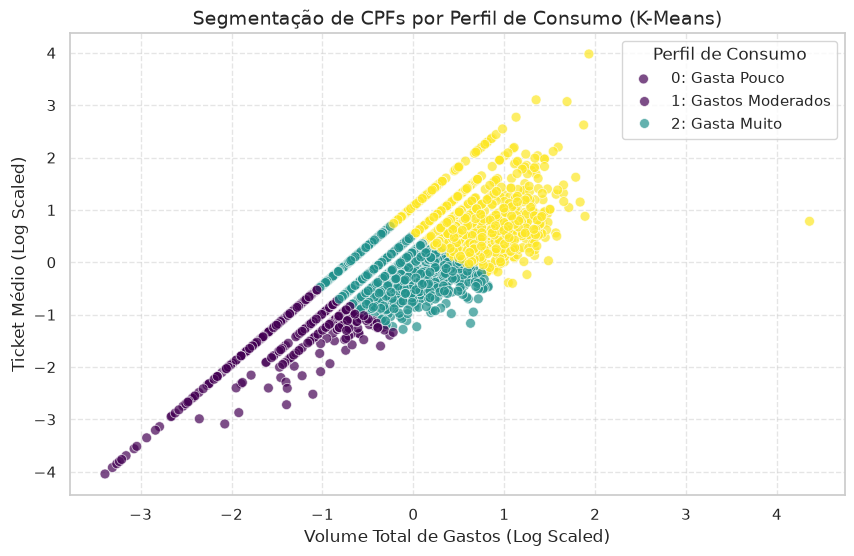

In [4]:
# Plotando o gráfico de dispersão dos perfis de consumo
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x='VOLUME_TOTAL_LOG_SCALED',
    y='TICKET_MEDIO_LOG_SCALED',
    hue='cluster_kmeans',
    palette='viridis',
    alpha=0.7,
    s=50
)

plt.title('Segmentação de CPFs por Perfil de Consumo (K-Means)', fontsize=14)
plt.xlabel('Volume Total de Gastos (Log Scaled)', fontsize=12)
plt.ylabel('Ticket Médio (Log Scaled)', fontsize=12)
plt.legend(title='Perfil de Consumo', labels=['0: Gasta Pouco', '1: Gastos Moderados', '2: Gasta Muito'])
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

**Explicação das Métricas**

### Avaliação da Qualidade dos Grupos (Métricas)


Para garantir que os CPFs foram bem separados, podemos calcular métricas de validação de clusters:
1. **Inércia (Within-Cluster Sum of Squares):** Mede o quão compactos são os clusters (quanto menor, mais unidos os pontos são dentro do mesmo grupo).
2. **Coeficiente de Silhueta (Silhouette Score):** Mede o quão bem separados os grupos estão uns dos outros. Varia de `-1` a `1`:
   - Próximo de `1`: Os grupos estão bem definidos e separados.
   - Próximo de `0`: Há sobreposição entre os grupos.
   - Negativo: Os pontos podem estar no grupo errado.

---



Utilizamos o Coeficiente de Silhueta para medir a separação dos clusters e a Inércia para garantir a compactação interna de cada grupo de gasto. K-Means agrupou os CPFs geometricamente com base no volume total e no ticket médio normalizados, e depois ordenamos as etiquetas de 0 a 2 em ordem crescente de consumo.



In [5]:
from sklearn.metrics import silhouette_score

# 1. Inércia (WSS) - quanto menor, mais coeso é o agrupamento
inercia = kmeans.inertia_
print(f"Inércia do Modelo (Compactação): {inercia:.2f}")

# 2. Coeficiente de Silhueta - avalia a separação entre os 3 perfis
score_silhueta = silhouette_score(X, df['cluster_kmeans'])
print(f"Coeficiente de Silhueta Médio: {score_silhueta:.4f}")

# Estatísticas descritivas de cada grupo para justificar as métricas na prática
print("\nMédia de Gastos e Ticket por Perfil:")
resumo_clusters = df.groupby('cluster_kmeans')[['VOLUME_TOTAL_LOG_SCALED', 'TICKET_MEDIO_LOG_SCALED']].agg(['mean', 'count'])
display(resumo_clusters)

Inércia do Modelo (Compactação): 1145.64
Coeficiente de Silhueta Médio: 0.4126

Média de Gastos e Ticket por Perfil:


VOLUME_TOTAL_LOG_SCALED       TICKET_MEDIO_LOG_SCALED      
                                  mean count                    mean count
cluster_kmeans                                                            
0                            -1.313684   423               -1.375282   423
1                            -0.182750  1377               -0.202661  1377
2                             0.649219  1010                0.751986  1010

## Isolation Forest

Tem como objetivo detectar portadores com comportamentos atípicos ou indícios de desvios na base de dados de gastos públicos. Para isso, utilizaremos o algoritmo de aprendizado de máquina não supervisionado Isolation Forest.

O que será feito neste notebook:
1. **Seleção de Variáveis e Tratamento:** Filtragem das principais métricas comportamentais (volume de transações, ticket médio, volatilidade, percentual de saques e sigilo) e tratamento de valores nulos.

2. **Treinamento do Modelo (Isolation Forest):** O algoritmo isolará as observações que se diferenciam do restante da base, configurado para sinalizar o top 1% mais anômalo (contamination=0.01).

3. **Tradução Lógica do Alerta:** Mapeamento da saída do modelo para criar a coluna booleana alerta_fraude, identificando claramente os portadores suspeitos.

4. **Visualização do Comportamento Atípico:** Geração de um gráfico de dispersão comparando o volume total versus o ticket médio, destacando visualmente os casos normais em verde e os alertas em vermelho.

5. **Auditoria dos Casos Isolados: **Filtragem e exibição detalhada dos principais portadores suspeitos ordenados pelo maior volume financeiro, direcionando a investigação para a tomada de decisão.

**Seleção de features preparadas**

Nesta etapa, foram importadas as bibliotecas essenciais para manipulação de dados, visualização e modelagem e selecionado o conjunto de features comportamentais (features_modelos) que inclui métricas como quantidade de transações, volume total, ticket médio, volatilidade, percentual de saques e sigilo, seguido pelo tratamento de valores nulos mediante a substituição por zero para garantir a integridade dos dados na alimentação do algoritmo Isolation Forest.

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

# Alimentando o modelo

features_modelos = [
    'QTD_TRANSACOES_LOG_SCALED',
    'VOLUME_TOTAL_LOG_SCALED',
    'TICKET_MEDIO_LOG',
    'VOLATILIDADE_STD_LOG',
    'PCT_SAQUES',
    'PCT_SIGILO'
]

# Conferindo se tem valor nulo nas variáveis de treino
df[features_modelos] = df[features_modelos].fillna(0)

**Instanciamento e treinamento do Isolation Forest**

Nesta etapa, o modelo Isolation Forest foi instanciado com cem árvores de decisão e configurado com um fator de contaminação de um por cento (contamination=0.01) para isolar os portadores mais atípicos, sendo treinado e executado sobre as features selecionadas através do método fit_predict para atribuir um escore numérico a cada registro. Em seguida, o resultado retornado composto por valores indicativos onde -1 representa desvios foi traduzido para uma coluna booleana (alerta_fraude), finalizando com a contagem da distribuição dos alertas gerados na base de dados.

In [7]:
# Orienta o modelo a marcar o top 1% mais anômalo

modelo = IsolationForest(n_estimators=100, contamination=0.01, random_state=42)

# O modelo avalia cada portador e retorna 1 ou -1

df['score_anomalia'] = modelo.fit_predict(df[features_modelos])

# Tradução de -1 para True (é anomalia) para o filtro

df['alerta_fraude'] = df['score_anomalia'] == -1

print(df['alerta_fraude'].value_counts())

alerta_fraude
False    2781
True       29
Name: count, dtype: int64


**Visualização do comportamento atípico**

Este grafico de dispersao exibe o mapeamento dos portadores cruzando o volume total e o ticket medio ambos em escala logaritmica. Os pontos em verde representam o comportamento normal enquanto os pontos em vermelho destacam os casos classificados como alerta de fraude pelo algoritmo Isolation Forest. E possivel observar que o modelo isolou estrategicamente as observacoes mais distantes da massa principal de dados como os pontos isolados na extremidade direita e nas pontas da distribuicao indicando desvios comportamentais que fogem do padrao esperado.

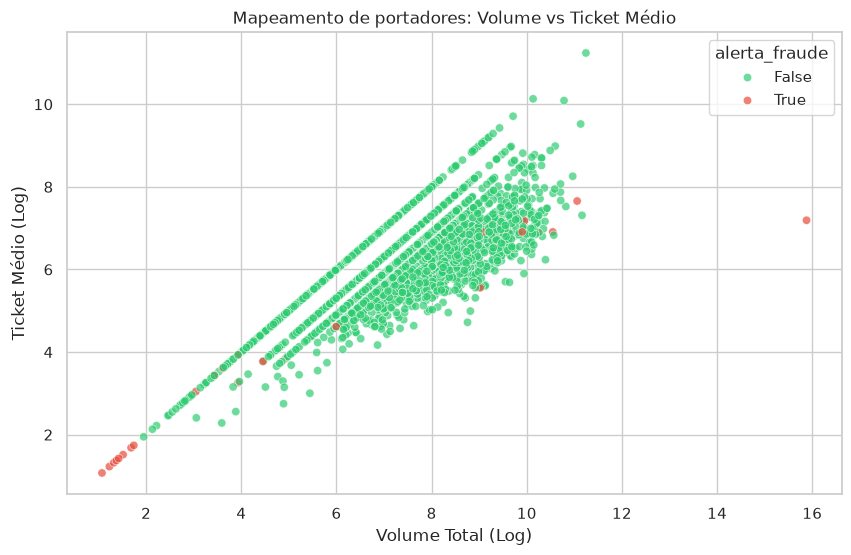

In [8]:
plt.figure(figsize=(10, 6))

# Plotando o volume total vs ticket médio

sns.scatterplot(
    data=df,
    x='VOLUME_TOTAL_LOG',
    y='TICKET_MEDIO_LOG',
    hue='alerta_fraude',
    palette={False: '#2ecc71', True: '#e74c3c'},
    alpha=0.7

)

plt.title('Mapeamento de portadores: Volume vs Ticket Médio')
plt.xlabel('Volume Total (Log)')
plt.ylabel('Ticket Médio (Log)')
plt.show()

**Auditoria dos casos isolados**

Esta etapa realiza a filtragem e a exibição dos portadores classificados como anômalos pelo modelo, organizando os registros em ordem decrescente pelo volume total de gastos para destacar os casos mais críticos. O código seleciona colunas estratégicas de auditoria, como o hash do CPF, a quantidade de transações, o volume financeiro, o ticket médio e os percentuais de saques e sigilo, apresentando uma tabela interativa com os dez principais suspeitos para orientar a análise investigativa inicial.

In [9]:
# Filtrando apenas os portadores anômalos e trazendo as colunas para leitura

portadores_suspeitos = df[df['alerta_fraude']].sort_values(by='VOLUME_TOTAL', ascending=False)

colunas_auditoria = [
    'HASH_CPF_PORTADOR',
    'QTD_TRANSACOES',
    'VOLUME_TOTAL',
    'TICKET_MEDIO',
    'PCT_SAQUES',
    'PCT_SIGILO'
]

display(portadores_suspeitos[colunas_auditoria].head(10))

,HASH_CPF_PORTADOR,QTD_TRANSACOES,VOLUME_TOTAL,TICKET_MEDIO,PCT_SAQUES,PCT_SIGILO
1717,HASH_NAO_INFORMADO,5934,7871500.64,1326.508365,0.000000,1.0
2059,bef51bb3efe382350b888e70397392e1040d088003a39b...,30,63429.90,2114.330000,0.200000,0.0
884,53bc0c4ee5c5ecbfe809625dc146832f5a3634901b6c85...,38,38000.00,1000.000000,1.000000,0.0
1533,8e47d2a453d5026bd08c24e2130cb5cb570a557d1eccc8...,28,27800.00,992.857143,1.000000,0.0
631,3e1e5868c7a92ad903d93ceaa056466cbee13c3e45f7ef...,16,20950.76,1309.422500,1.000000,0.0
2596,eda59412be9be5539c447294b36ed2be91a25a48e9e4c2...,20,20000.00,1000.000000,1.000000,0.0
993,5d6b50db49b6d6b513c43df0b659472d19e8e24da91eb8...,15,14990.00,999.333333,1.000000,0.0
1080,6495178ea1fc669f9d927c1ed8b52c0e7626dfea3b6856...,11,10999.27,999.933636,0.909091,0.0
1196,703c688c7a2b4fcb3272336c3a53ea82f6ece388e2642c...,8,9790.78,1223.847500,1.000000,0.0
1953,b6340de8120b206b17afe757d357c35f86c5d082aeb369...,9,9000.00,1000.000000,1.000000,0.0


## Cruzamento de Dados

O cruzamento analítico entre a segmentação de perfil do K-Means e a detecção de desvios do Isolation Forest é estritamente necessário porque isolar apenas os volumes altos ou apenas as anomalias estatísticas gera muitos falsos positivos, enquanto a união desses dois mundos filtra e restringe o escopo aos portadores que acumulam grande expressão financeira e comportamento estatisticamente atípico de forma simultânea. Essa abordagem deve ser tratada estritamente como um indicativo de transação suspeita e jamais como uma sentença ou confirmação de fraude, visto que os algoritmos baseiam-se em padrões matemáticos e geométricos que apontam desvios, exigindo obrigatoriamente uma auditoria humana subsequente para validar a conformidade documental e descartar justificativas legais legítimas antes de qualquer tomada de decisão punitiva.


---

O cruzamento de dados foi executado combinando de forma lógica as saídas dos dois modelos estatísticos e de machine learning previamente treinados no notebook. Primeiro, a rotulação gerada pelo K-Means foi filtrada para selecionar exclusivamente os portadores alocados no grupo de maior expressão financeira, correspondente ao cluster de alto consumo (cluster_kmeans == 2). Em seguida, esse subconjunto foi cruzado com o resultado booleano do Isolation Forest, que identifica as observações estatisticamente atípicas (alerta_fraude == True). Através de uma operação lógica do tipo "E" (&), a rotina gerou a nova coluna transacao_suspeita, atribuindo valor binário (1 para verdadeiro e 0 para falso) apenas aos registros que preenchem simultaneamente ambas as condições: pertencer ao perfil de maior volume de gastos e apresentar comportamento anômalo mapeado pelo isolamento. Por fim, o código contabilizou a quantidade e o percentual representativo desses registros na base total, ordenando os principais casos pelo maior volume de transações para exibir uma tabela consolidada de auditoria voltada a priorizar a investigação dos casos mais críticos.

In [11]:
## Cruzamento de Dados: K-Means + Isolation Forest

# 1. Cruzando o perfil de maior risco do K-Means (Cluster 2: Gasta Muito) com o alerta de fraude do Isolation Forest
df['transacao_suspeita'] = ((df['cluster_kmeans'] == 2) & (df['alerta_fraude'] == True)).astype(int)

# 2. Resumo quantitativo do cruzamento
total_geral = len(df)
total_suspeitos = df['transacao_suspeita'].sum()
percentual = (total_suspeitos / total_geral) * 100

print(f"Total de registros na base: {total_geral}")
print(f"Total de CPFs Altamente Suspeitos (Cluster 2 + Anomalia IF): {total_suspeitos} ({percentual:.2f}% da base)")

# 3. Exibindo a auditoria cruzada dos principais casos ordenados pelo maior volume de gastos
colunas_cruzamento = [
    'HASH_CPF_PORTADOR',
    'cluster_kmeans',
    'QTD_TRANSACOES',
    'VOLUME_TOTAL',
    'TICKET_MEDIO',
    'PCT_SAQUES',
    'PCT_SIGILO'
]

print("\nTop 10 Portadores Mais Suspeitos (Foco de Auditoria):")
display(df[df['transacao_suspeita'] == 1][colunas_cruzamento].sort_values(by='VOLUME_TOTAL', ascending=False).head(10))

Total de registros na base: 2810
Total de CPFs Altamente Suspeitos (Cluster 2 + Anomalia IF): 11 (0.39% da base)

Top 10 Portadores Mais Suspeitos (Foco de Auditoria):


,HASH_CPF_PORTADOR,cluster_kmeans,QTD_TRANSACOES,VOLUME_TOTAL,TICKET_MEDIO,PCT_SAQUES,PCT_SIGILO
1717,HASH_NAO_INFORMADO,2,5934,7871500.64,1326.508365,0.000000,1.0
2059,bef51bb3efe382350b888e70397392e1040d088003a39b...,2,30,63429.90,2114.330000,0.200000,0.0
884,53bc0c4ee5c5ecbfe809625dc146832f5a3634901b6c85...,2,38,38000.00,1000.000000,1.000000,0.0
1533,8e47d2a453d5026bd08c24e2130cb5cb570a557d1eccc8...,2,28,27800.00,992.857143,1.000000,0.0
631,3e1e5868c7a92ad903d93ceaa056466cbee13c3e45f7ef...,2,16,20950.76,1309.422500,1.000000,0.0
2596,eda59412be9be5539c447294b36ed2be91a25a48e9e4c2...,2,20,20000.00,1000.000000,1.000000,0.0
993,5d6b50db49b6d6b513c43df0b659472d19e8e24da91eb8...,2,15,14990.00,999.333333,1.000000,0.0
1080,6495178ea1fc669f9d927c1ed8b52c0e7626dfea3b6856...,2,11,10999.27,999.933636,0.909091,0.0
1196,703c688c7a2b4fcb3272336c3a53ea82f6ece388e2642c...,2,8,9790.78,1223.847500,1.000000,0.0
1953,b6340de8120b206b17afe757d357c35f86c5d082aeb369...,2,9,9000.00,1000.000000,1.000000,0.0


##Relatório em PDF

Esta etapa final do processo consiste na exportação automatizada de um relatório executivo em formato PDF estruturado profissionalmente para servir de insumo direto ao auditor humano, a quem cabe a responsabilidade intransferível pela investigação e tomada de decisão. O script instala as dependências necessárias e configura um documento corporativo contendo um resumo executivo seguido por uma tabela detalhada com os principais portadores suspeitos priorizados pelo maior volume financeiro. O material gerado fornece as diretrizes práticas de auditoria e compila o arquivo final para download automático, garantindo que o auditor disponha de um suporte documental robusto e organizado para realizar a triagem investigativa com total segurança e discernimento humano.

In [12]:
from reportlab.lib.pagesizes import letter
from reportlab.lib import colors
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle, HRFlowable
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle

if not github_token:
    raise ValueError(" Erro: GITHUB_TOKEN não encontrado no arquivo .env.")

# 1. Configura os caminhos para a pasta docs na RAIZ do projeto
caminho_pasta_local = "../docs"
caminho_pasta_repo = "docs"
nome_arquivo = "relatorio_transacoes_suspeitas.pdf"

os.makedirs(caminho_pasta_local, exist_ok=True)
pdf_filename = os.path.join(caminho_pasta_local, nome_arquivo)

# 2. Configurações do Documento
doc = SimpleDocTemplate(pdf_filename, pagesize=letter, rightMargin=36, leftMargin=36, topMargin=36, bottomMargin=36)
story = []
styles = getSampleStyleSheet()

PRIMARY_COLOR = colors.HexColor("#1A365D")
BG_LIGHT = colors.HexColor("#F7FAFC")
TEXT_DARK = colors.HexColor("#2D3748")

title_style = ParagraphStyle('DocTitle', parent=styles['Heading1'], fontName='Helvetica-Bold', fontSize=18, textColor=PRIMARY_COLOR)
table_header_style = ParagraphStyle('TableHeader', parent=styles['Normal'], fontName='Helvetica-Bold', fontSize=8, textColor=colors.white, alignment=1)
table_cell_style = ParagraphStyle('TableCell', parent=styles['Normal'], fontName='Helvetica', fontSize=8, textColor=TEXT_DARK, alignment=1)

story.append(Paragraph("Relatório de Auditoria: Transações e Portadores Suspeitos", title_style))
story.append(HRFlowable(width="100%", thickness=1.5, color=PRIMARY_COLOR, spaceAfter=12))

# 3. Construção da Tabela com os Top Suspeitos
try:
    df_suspeitos = df[df['transacao_suspeita'] == 1].sort_values(by='VOLUME_TOTAL', ascending=False).head(10)
except:
    df_suspeitos = df.head(5)

headers = ["Hash CPF Portador", "Qtd Trans.", "Volume Total", "Ticket Médio", "% Saques", "% Sigilo"]
table_data = [[Paragraph(h, table_header_style) for h in headers]]

for _, row in df_suspeitos.iterrows():
    cpf_hash = str(row.get('HASH_CPF_PORTADOR', 'N/D'))
    table_data.append([
        Paragraph(f"{cpf_hash[:8]}...", table_cell_style),
        Paragraph(str(row.get('QTD_TRANSACOES', 0)), table_cell_style),
        Paragraph(f"R$ {row.get('VOLUME_TOTAL', 0):,.2f}", table_cell_style),
        Paragraph(f"R$ {row.get('TICKET_MEDIO', 0):,.2f}", table_cell_style),
        Paragraph(f"{row.get('PCT_SAQUES', 0)*100:.1f}%", table_cell_style),
        Paragraph(f"{row.get('PCT_SIGILO', 0)*100:.1f}%", table_cell_style),
    ])

t = Table(table_data, colWidths=[140, 60, 90, 80, 65, 65])
t.setStyle(TableStyle([
    ('BACKGROUND', (0, 0), (-1, 0), PRIMARY_COLOR),
    ('ALIGN', (0, 0), (-1, -1), 'CENTER'),
    ('GRID', (0, 0), (-1, -1), 0.5, colors.HexColor("#E2E8F0")),
    ('ROWBACKGROUNDS', (0, 1), (-1, -1), [colors.white, BG_LIGHT]),
]))

story.append(t)

# Compila o PDF na pasta ../docs
doc.build(story)
print(f"Relatório PDF gerado localmente em: {pdf_filename}")

# 4. Envio Automático para o GitHub
owner = "MaiccGms8"
repo = "gov-spend-analyzer"
branch = "main"
caminho_completo_repo = f"{caminho_pasta_repo}/{nome_arquivo}"

with open(pdf_filename, "rb") as pdf_file:
    pdf_base64 = base64.b64encode(pdf_file.read()).decode("utf-8")

api_url = f"https://api.github.com/repos/{owner}/{repo}/contents/{caminho_completo_repo}"
headers_gh = {"Authorization": f"token {github_token}", "Accept": "application/vnd.github.v3+json"}

response_get = requests.get(api_url, headers=headers_gh)
sha = response_get.json().get("sha") if response_get.status_code == 200 else None

payload = {
    "message": "feat: atualiza relatório PDF de auditoria",
    "content": pdf_base64,
    "branch": branch
}
if sha:
    payload["sha"] = sha

response_put = requests.put(api_url, headers=headers_gh, json=payload)

if response_put.status_code in [200, 201]:
    print(f"Sucesso! Relatório enviado para a pasta '{caminho_pasta_repo}' no GitHub.")
else:
    print(f"Erro ao enviar para o GitHub. Status code: {response_put.status_code}")

Relatório PDF gerado localmente em: ../docs/relatorio_transacoes_suspeitas.pdf
Sucesso! Relatório enviado para a pasta 'docs' no GitHub.
